In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn yfinance


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [4]:
df = yf.download('AAPL', start='2019-01-01', end='2024-01-01')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1258, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.469204,37.689864,36.593688,36.750285,148158800
2019-01-03,33.736996,34.574548,33.691914,34.161702,365248800
2019-01-04,35.177216,35.246025,34.119006,34.292210,234428400
2019-01-07,35.098911,35.312454,34.617259,35.281608,219111200
2019-01-08,35.768002,36.021879,35.238897,35.485653,164101200


In [5]:
# We'll predict the next day's closing price
# Use only the 'Close' price column
df = df[['Close']].copy()

# Create lag features (yesterday's price, 2 days ago, 3 days ago)
df['Lag_1'] = df['Close'].shift(1)  # yesterday's price
df['Lag_2'] = df['Close'].shift(2)  # 2 days ago
df['Lag_3'] = df['Close'].shift(3)  # 3 days ago

# Rolling average (average of last 7 days)
df['MA_7'] = df['Close'].rolling(window=7).mean()

# Rolling average (average of last 21 days)
df['MA_21'] = df['Close'].rolling(window=21).mean()

# Drop rows with missing values (first few rows will have NaN)
df.dropna(inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (1238, 6)


Price,Close,Lag_1,Lag_2,Lag_3,MA_7,MA_21
Ticker,AAPL,,,,,
Date,,,,,,
2019-01-31,39.490726,39.208374,36.700459,37.084827,37.523776,36.578549
2019-02-01,39.509701,39.490726,39.208374,36.700459,37.950857,36.675716
2019-02-04,40.631966,39.509701,39.490726,39.208374,38.579613,37.004048
2019-02-05,41.327156,40.631966,39.509701,39.490726,39.136173,37.296902
2019-02-06,41.341400,41.327156,40.631966,39.509701,39.744255,37.594163


In [6]:
# We'll predict the next day's closing price
# Use only the 'Close' price column
df = df[['Close']].copy()

# Create lag features (yesterday's price, 2 days ago, 3 days ago)
df['Lag_1'] = df['Close'].shift(1)  # yesterday's price
df['Lag_2'] = df['Close'].shift(2)  # 2 days ago
df['Lag_3'] = df['Close'].shift(3)  # 3 days ago

# Rolling average (average of last 7 days)
df['MA_7'] = df['Close'].rolling(window=7).mean()

# Rolling average (average of last 21 days)
df['MA_21'] = df['Close'].rolling(window=21).mean()

# Drop rows with missing values (first few rows will have NaN)
df.dropna(inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (1218, 6)


Price,Close,Lag_1,Lag_2,Lag_3,MA_7,MA_21
Ticker,AAPL,,,,,
Date,,,,,,
2019-03-01,41.692657,41.258976,41.668819,41.540142,41.379141,40.847298
2019-03-04,41.902355,41.692657,41.258976,41.668819,41.542195,40.962137
2019-03-05,41.826103,41.902355,41.692657,41.258976,41.629341,41.072442
2019-03-06,41.585423,41.826103,41.902355,41.692657,41.639211,41.117845
2019-03-07,41.104084,41.585423,41.826103,41.902355,41.576917,41.107222


In [7]:
# Define features (X) and target (y)
X = df[['Lag_1', 'Lag_2', 'Lag_3', 'MA_7', 'MA_21']]
y = df['Close']

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False is important for time series!
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 974
Testing samples: 244


In [8]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE: 2.08
R² Score: 0.9831


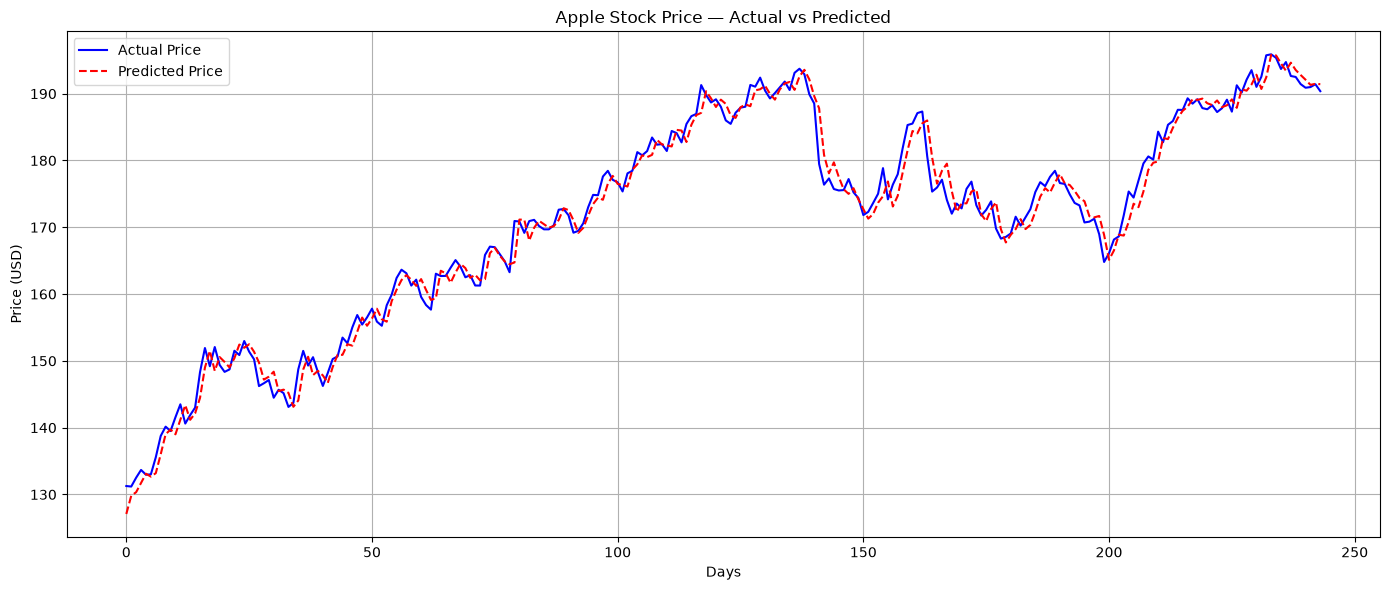

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red', linestyle='--')
plt.title('Apple Stock Price — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

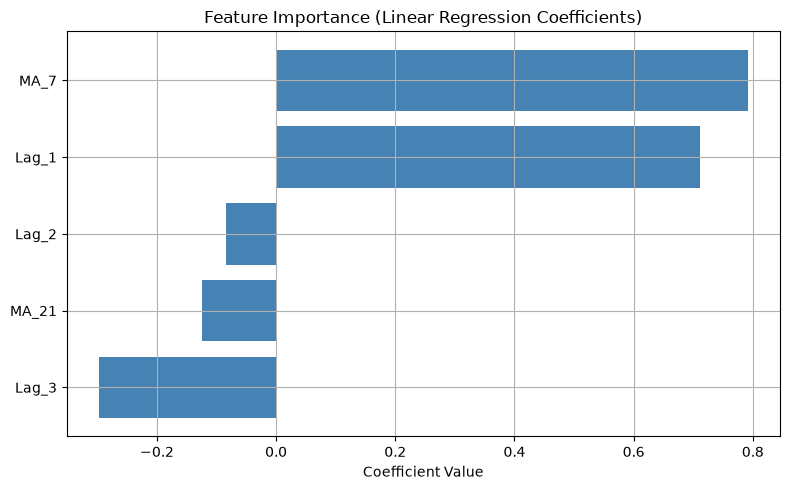

  Feature  Coefficient
2   Lag_3    -0.296944
4   MA_21    -0.124264
1   Lag_2    -0.084065
0   Lag_1     0.711271
3    MA_7     0.791182


In [10]:
# Fix for yfinance multi-level columns issue
coefficients = pd.DataFrame({
    'Feature': ['Lag_1', 'Lag_2', 'Lag_3', 'MA_7', 'MA_21'],
    'Coefficient': model.coef_.flatten()  # flatten fixes the dimension issue
})

coefficients = coefficients.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.grid(True)
plt.tight_layout()
plt.show()

print(coefficients)

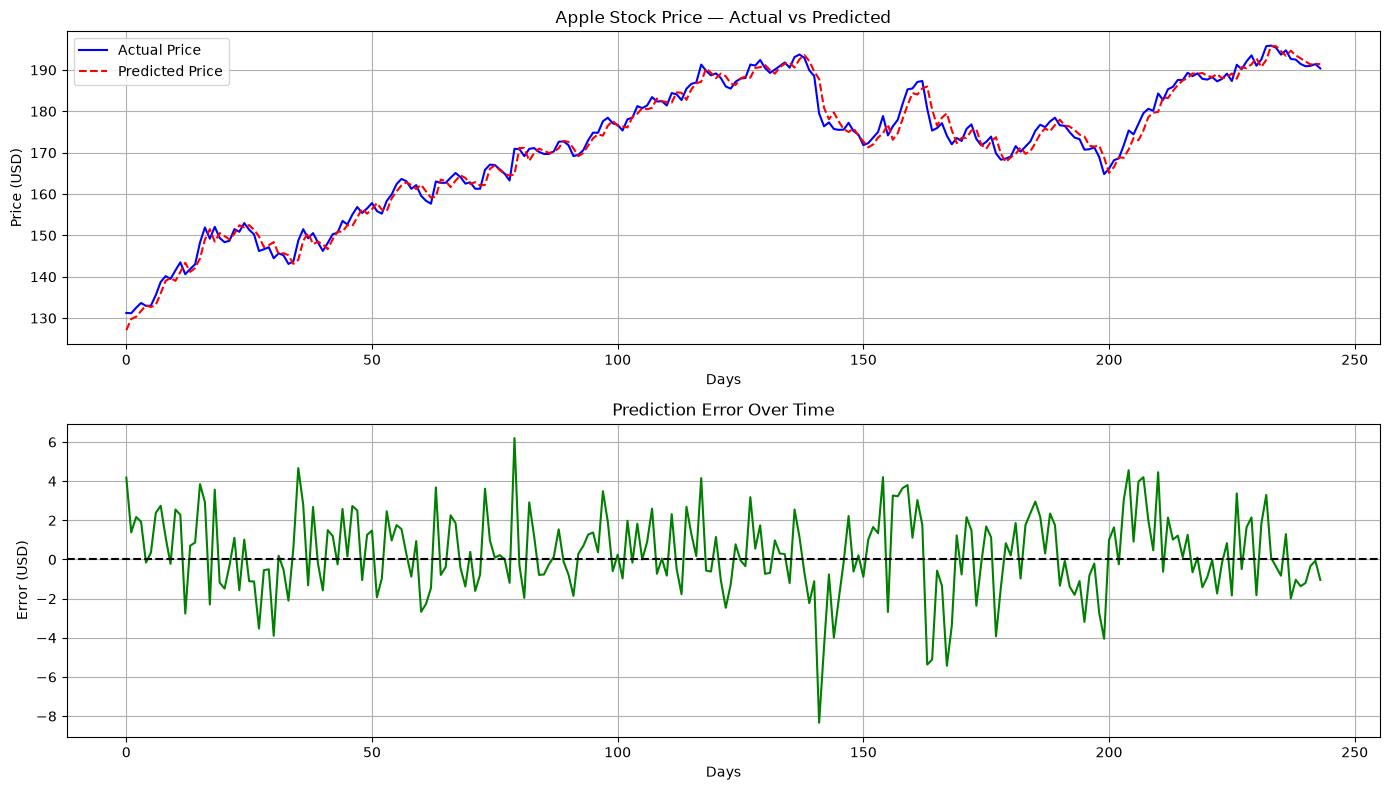

In [11]:
plt.figure(figsize=(14, 8))

# Plot 1: Actual vs Predicted
plt.subplot(2, 1, 1)
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red', linestyle='--')
plt.title('Apple Stock Price — Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

# Plot 2: Prediction Error
plt.subplot(2, 1, 2)
errors = y_test.values - y_pred
plt.plot(errors, color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Prediction Error Over Time')
plt.xlabel('Days')
plt.ylabel('Error (USD)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Create a dataframe with actual and predicted prices
signal_df = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': y_pred.flatten()
}, index=y_test.index)

# Generate signal
# If predicted price > today's actual price → BUY, else SELL
signal_df['Signal'] = signal_df['Predicted'] > signal_df['Actual']
signal_df['Signal'] = signal_df['Signal'].map({True: 'BUY', False: 'SELL'})

print(signal_df.head(10))
print("\nBUY signals:", (signal_df['Signal'] == 'BUY').sum())
print("SELL signals:", (signal_df['Signal'] == 'SELL').sum())

                Actual   Predicted Signal
Date                                     
2023-01-11  131.262222  127.079041   SELL
2023-01-12  131.183548  129.798065   SELL
2023-01-13  132.511032  130.340485   SELL
2023-01-17  133.671310  131.741358   SELL
2023-01-18  132.953491  133.107177    BUY
2023-01-19  133.012497  132.669502   SELL
2023-01-20  135.569077  133.188807   SELL
2023-01-23  138.755066  136.011044   SELL
2023-01-24  140.151337  139.017103   SELL
2023-01-25  139.492493  139.716291    BUY

BUY signals: 113
SELL signals: 131


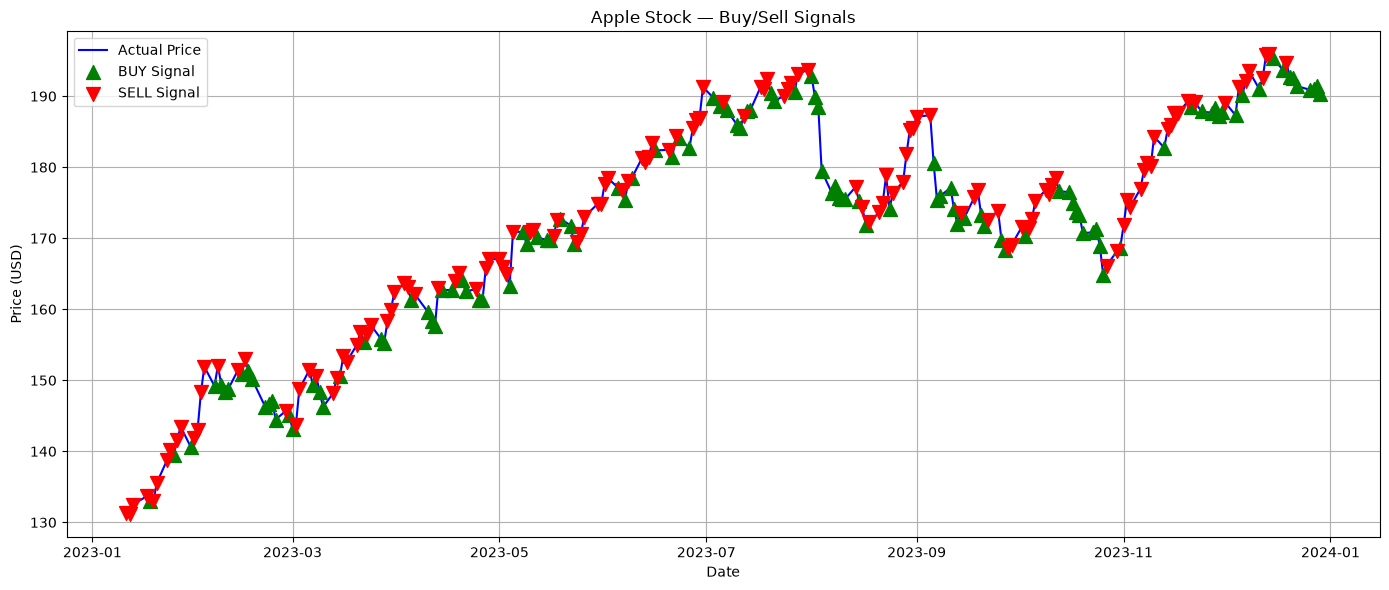

In [13]:
plt.figure(figsize=(14, 6))

# Plot actual price
plt.plot(signal_df.index, signal_df['Actual'], label='Actual Price', color='blue', linewidth=1.5)

# Plot BUY signals (green arrows pointing up)
buy = signal_df[signal_df['Signal'] == 'BUY']
plt.scatter(buy.index, buy['Actual'], marker='^', color='green', s=100, label='BUY Signal', zorder=5)

# Plot SELL signals (red arrows pointing down)
sell = signal_df[signal_df['Signal'] == 'SELL']
plt.scatter(sell.index, sell['Actual'], marker='v', color='red', s=100, label='SELL Signal', zorder=5)

plt.title('Apple Stock — Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()